#Reguralization
A method to avoid overfitting that means it performs well on the training data where the mse = 0 but performs poor on the testing data in that case it leads to high variance(overfiitng) but low bias(as the training dats fits perfectly),to reduce the high variance(overfitting) we intoduce reguralization L1,L2 reguralization as a penealty term to the loss(MSE) to penalize the large weights

Without regularisation, your model minimises only the prediction error(MSE) on training data. It will make weights as large as needed to fit every point — including noise.
This causes overfitting.

Regularisation adds a second term to the loss function that penalises large weights. Now the model has two goals: fit the data AND keep weights small. This forces it to find a simpler solution that generalises better.

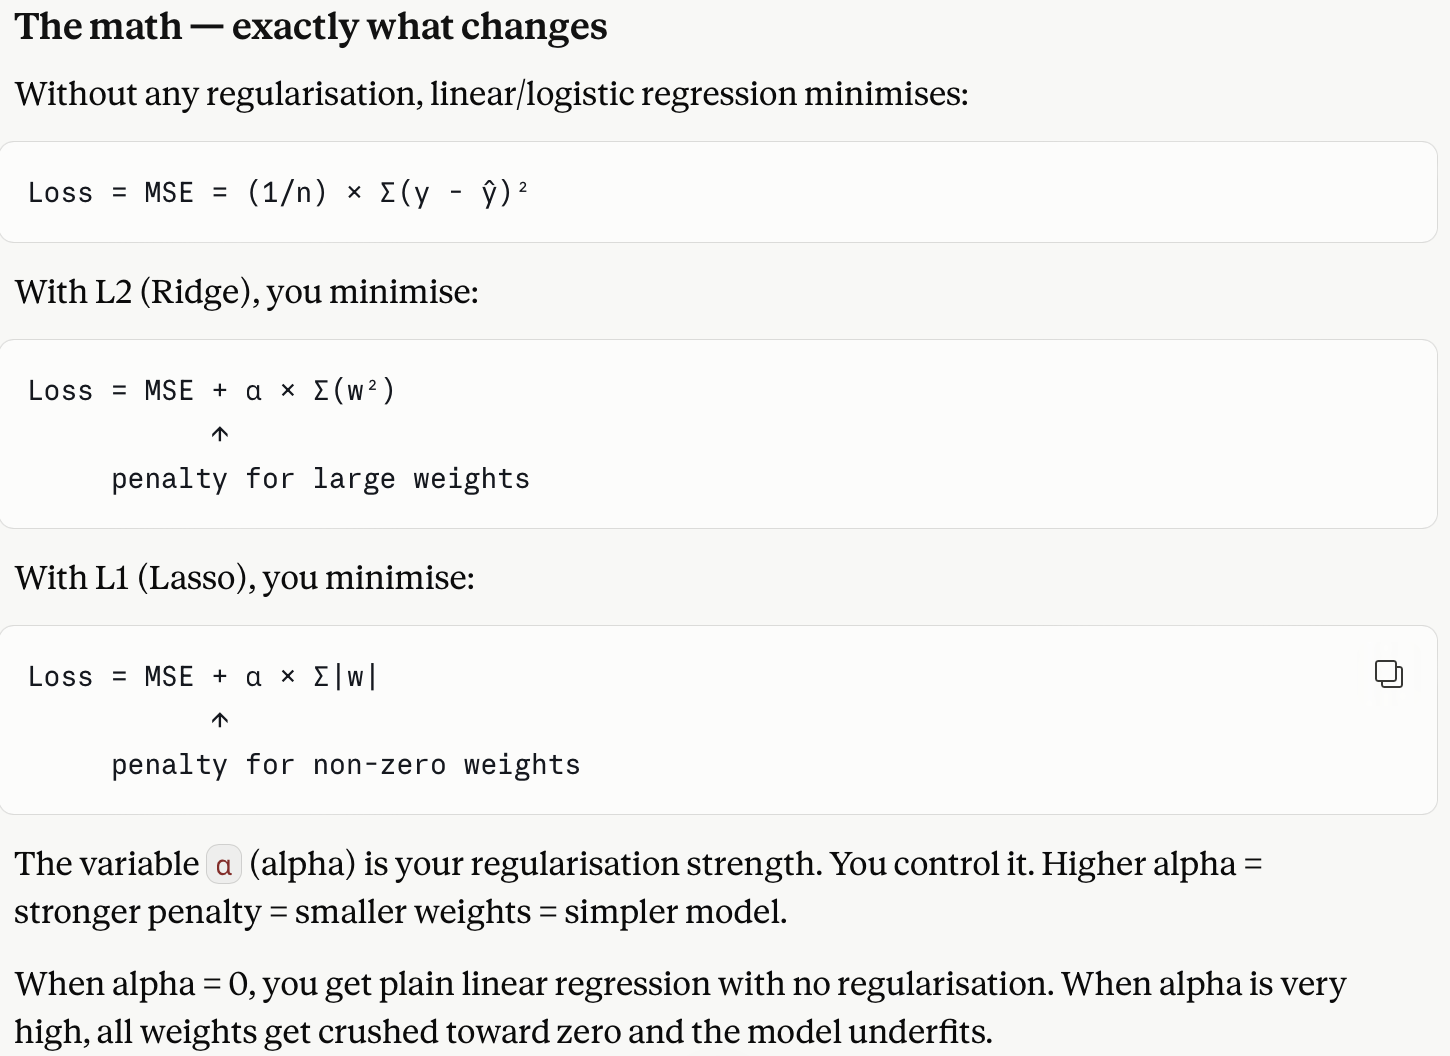

#When to use which
Use Ridge when: you believe all your features carry some signal, features are correlated with each other (e.g. height and weight), you want a stable model.

Use Lasso when: you have many features (20+) and suspect most are irrelevant, you want the model to automatically tell you which features matter, you want a sparse interpretable model.

Use ElasticNet when: you're unsure between L1 and L2, you have many correlated features but also want some zeroed out, it's a competition and you want to cover both bases.

Use neither when: you're using tree-based models (Random Forest, XGBoost) — they don't use weight penalties. For trees, regularisation comes from max_depth, min_samples_leaf, and n_estimators.

Implementation of how reguralization is used in ML algorithms

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
dataset = pd.read_csv('/content/Melbourne_housing.csv')
dataset.head()

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Carport,NaN
1,Airport West,154 Halsey Rd,3,t,PI,Nelson,3/9/2016,13.5,3042.0,3.0,...,303.0,225,2016.0,Moonee Valley City Council,-37.7180,144.8780,Western Metropolitan,3464.0,Detached Garage,840000.0
2,Albert Park,105 Kerferd Rd,2,h,S,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,120.0,82,1900.0,Port Phillip City Council,-37.8459,144.9555,Southern Metropolitan,3280.0,Attached Garage,1275000.0
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.8450,144.9538,Southern Metropolitan,3280.0,Indoor,1455000.0
4,Alphington,30 Austin St,3,h,SN,McGrath,3/9/2016,6.4,3078.0,3.0,...,174.0,122,2003.0,Darebin City Council,-37.7818,145.0198,Northern Metropolitan,2211.0,Parkade,NaN


Do dataset cleaning and preprocessing

In [8]:
dataset.nunique()

,0
Suburb,351
Address,34009
Rooms,12
Type,3
Method,9
SellerG,388
Date,78
Distance,215
Postcode,211
Bedroom,15


Discard certain colums which feels useless to you

In [11]:
cols_to_use = ['Suburb', 'Rooms', 'Type', 'Method', 'SellerG', 'Regionname', 'Propertycount' ,
'Distance', 'CouncilArea', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Price']
dataset = dataset[cols_to_use]

In [12]:
dataset

,Suburb,Rooms,Type,Method,SellerG,Regionname,Propertycount,Distance,CouncilArea,Bedroom,Bathroom,Car,Landsize,BuildingArea,Price
0,Abbotsford,2,h,SS,Jellis,Northern Metropolitan,4019.0,2.5,Yarra City Council,2.0,1.0,1.0,126.0,inf,NaN
1,Airport West,3,t,PI,Nelson,Western Metropolitan,3464.0,13.5,Moonee Valley City Council,3.0,2.0,1.0,303.0,225,840000.0
2,Albert Park,2,h,S,hockingstuart,Southern Metropolitan,3280.0,3.3,Port Phillip City Council,2.0,1.0,0.0,120.0,82,1275000.0
3,Albert Park,2,h,S,Thomson,Southern Metropolitan,3280.0,3.3,Port Phillip City Council,2.0,1.0,0.0,159.0,inf,1455000.0
4,Alphington,3,h,SN,McGrath,Northern Metropolitan,2211.0,6.4,Darebin City Council,3.0,2.0,1.0,174.0,122,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,Reservoir,3,u,SP,RW,Northern Metropolitan,21650.0,12.0,Darebin City Council,3.0,1.0,1.0,NaN,105.0,475000.0
34853,Roxburgh Park,4,h,S,Raine,Northern Metropolitan,5833.0,20.6,Hume City Council,4.0,2.0,2.0,NaN,225.0,591000.0
34854,Springvale South,4,h,PI,Barry,South-Eastern Metropolitan,4054.0,22.2,Greater Dandenong City Council,4.0,2.0,2.0,534.0,152.0,NaN
34855,Springvale South,3,h,S,Harcourts,South-Eastern Metropolitan,4054.0,22.2,Greater Dandenong City Council,3.0,2.0,1.0,544.0,NaN,780500.0


In [14]:
dataset.shape

(34857, 15)

Now handle missing values in it

In [15]:
dataset.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
Method,0
SellerG,0
Regionname,0
Propertycount,3
Distance,1
CouncilArea,3
Bedroom,8217


In [31]:
import numpy as np
cols_to_fill_zero = ['Propertycount', 'Distance',
'Bedroom', 'Bathroom', 'Car']
dataset [cols_to_fill_zero] = dataset[cols_to_fill_zero].fillna(0)

# Convert to numeric, coercing errors, before calculating mean
dataset['Landsize'] = pd.to_numeric(dataset['Landsize'], errors='coerce')
dataset['BuildingArea'] = pd.to_numeric(dataset['BuildingArea'], errors='coerce')

# Replace infinite values with NaN for Landsize and BuildingArea
dataset['Landsize'] = dataset['Landsize'].replace([np.inf, -np.inf], np.nan)
dataset['BuildingArea'] = dataset['BuildingArea'].replace([np.inf, -np.inf], np.nan)

dataset['Landsize'] = dataset['Landsize'].fillna(dataset.Landsize.mean())
dataset['BuildingArea'] = dataset['BuildingArea'].fillna(dataset.BuildingArea.mean())
dataset.isna().sum()

,0
Rooms,0
Propertycount,0
Distance,0
Bedroom,0
Bathroom,0
...,...
CouncilArea_Whitehorse City Council,0
CouncilArea_Whittlesea City Council,0
CouncilArea_Wyndham City Council,0
CouncilArea_Yarra City Council,0


In [20]:
dataset.dropna(inplace = True)
dataset.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
Method,0
SellerG,0
Regionname,0
Propertycount,0
Distance,0
CouncilArea,0
Bedroom,0


In [23]:
dataset = pd.get_dummies(dataset, drop_first=True) # do this to avoid text rows so only numerics are there
dataset.head()

,Rooms,Propertycount,Distance,Bedroom,Bathroom,Car,Landsize,BuildingArea,Price,Suburb_Aberfeldie,...,CouncilArea_Moorabool Shire Council,CouncilArea_Moreland City Council,CouncilArea_Nillumbik Shire Council,CouncilArea_Port Phillip City Council,CouncilArea_Stonnington City Council,CouncilArea_Whitehorse City Council,CouncilArea_Whittlesea City Council,CouncilArea_Wyndham City Council,CouncilArea_Yarra City Council,CouncilArea_Yarra Ranges Shire Council
1,3,3464.0,13.5,3.0,2.0,1.0,303.0,225.0,840000.0,False,...,False,False,False,False,False,False,False,False,False,False
2,2,3280.0,3.3,2.0,1.0,0.0,120.0,82.0,1275000.0,False,...,False,False,False,True,False,False,False,False,False,False
3,2,3280.0,3.3,2.0,1.0,0.0,159.0,inf,1455000.0,False,...,False,False,False,True,False,False,False,False,False,False
5,4,2211.0,6.4,3.0,2.0,4.0,853.0,263.0,2000000.0,False,...,False,False,False,False,False,False,False,False,False,False
6,3,2211.0,6.4,3.0,2.0,2.0,208.0,inf,1110000.0,False,...,False,False,False,False,False,False,False,False,False,False


In [25]:
X = dataset.drop('Price',axis = 1)
y = dataset['Price']

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)


In [36]:
from sklearn.linear_model import LinearRegression

# Ensure X_train does not contain infinite values just before fitting
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train.fillna(X_train.mean(), inplace=True)

reg = LinearRegression().fit(X_train, y_train)

In [41]:
import numpy as np

# Ensure X_test does not contain infinite values or NaNs before scoring
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

# Calculate and display both training and testing R-squared scores for Linear Regression
linear_reg_train_score = reg.score(X_train, y_train)
linear_reg_test_score = reg.score(X_test, y_test)

print(f"Linear Regression - R-squared on Training Data: {linear_reg_train_score:.4f}")
print(f"Linear Regression - R-squared on Test Data: {linear_reg_test_score:.4f}")

Linear Regression - R-squared on Training Data: 0.6820
Linear Regression - R-squared on Test Data: 0.6624


In [38]:
reg.score(X_test,y_test)

0.6624434644602326

## Exploring Regularization with Ridge Regression

To demonstrate how regularization can impact model performance and address overfitting, we'll use `Ridge` regression, which applies L2 regularization. This adds a penalty term to the loss function, encouraging smaller weights and thus simpler models that generalize better.

In [39]:
from sklearn.linear_model import Ridge

# Initialize and train a Ridge Regression model
# The 'alpha' parameter controls the strength of the regularization. Higher alpha means stronger regularization.
ridge_reg = Ridge(alpha=1.0) # You can experiment with different alpha values

# Fit the Ridge model on the *cleaned* training data
# X_train is already cleaned from the previous steps
ridge_reg.fit(X_train, y_train)

print('Ridge Regression Model Trained.')

Ridge Regression Model Trained.


In [40]:
# Evaluate the Ridge Regression model
ridge_train_score = ridge_reg.score(X_train, y_train)
ridge_test_score = ridge_reg.score(X_test, y_test)

print(f"Ridge Regression - R-squared on Training Data: {ridge_train_score:.4f}")
print(f"Ridge Regression - R-squared on Test Data: {ridge_test_score:.4f}")

# Retrieve the Linear Regression test score for comparison
# The previous Linear Regression model's test score was 0.6624
print(f"\nLinear Regression (without regularization) - R-squared on Test Data: {reg.score(X_test, y_test):.4f}")

Ridge Regression - R-squared on Training Data: 0.6813
Ridge Regression - R-squared on Test Data: 0.6657

Linear Regression (without regularization) - R-squared on Test Data: 0.6624


### Interpretation of Regularization Results

By comparing the R-squared scores:

*   **Standard Linear Regression (without regularization):** We previously got a test R-squared of `0.6624`.
*   **Ridge Regression (with L2 regularization):** Observe the training and test R-squared scores for the `ridge_reg` model.

Regularization (like Ridge) generally aims to achieve a better balance between bias and variance. While it might slightly reduce the training score (as it penalizes complex models that fit the training data perfectly), it can often lead to a test score that is closer to the training score or even slightly better, indicating improved generalization to unseen data and reduced overfitting. The strength of this effect depends on the `alpha` parameter. You can experiment with different `alpha` values (e.g., 0.1, 10, 100) to see how it influences the scores and the trade-off between bias and variance.

Interview questions on this topic

* What is the difference between L1 and L2 regularisation?
* Why does L1 produce sparse solutions (zeros) but L2 doesn't?
* What is the effect of increasing alpha in Ridge regression?
* When would you prefer Lasso over Ridge?
* What is ElasticNet and when would you use it?
* If you have 500 features and suspect most are irrelevant, which regularisation do you use?
* What happens to model weights when alpha is very high?




